## Telecom X - Análise de Evasão de Clientes (Churn)

Projeto de análise exploratória de dados desenvolvido para identificar padrões de evasão de clientes na empresa Telecom X.

Ferramentas utilizadas:

- Python
- Pandas
- Seaborn
- Matplotlib



## Introdução

A evasão de clientes (Churn) é um dos principais desafios para empresas de telecomunicações, pois representa a perda de clientes e impacta diretamente a receita da empresa.

O objetivo desta análise é explorar os dados da empresa Telecom X para identificar padrões relacionados ao cancelamento de clientes e gerar Insights que possam ajudar na criação de estratégias de retenção.

Para isso, foram realizadas etapas de importação, limpeza e análise exploratória dos dados, utilizando Python e bibliotecas de análise de dados.

In [ ]:
import pandas as pd
import requests

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"
data = requests.get(url).json()
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [ ]:
df.columns = df.columns.str.replace(".","_")

## Limpeza e Tratamento de Dados

Os dados foram importados a partir de um arquivo JSON disponível no Github. Como o arquivo possuía uma estrutura aninhada, foi necessário utilizar a função 'json_normalize()' para transformar os dados em um formato tabular adequado para análise.

Durante o processo de limpeza dos dados foram realizadas as seguintes etapas:

- Verificação de valores nulos
- Conversão de colunas numéricas para o formato adequado
- Remoção de registros inconsistentes
- Padronização dos nomes das colunas para facilitar a análise

Essas etapas garantiram que o dataset estivesse preparado para a análise exploratória.

## Análise Exploratória dos Dados

Durante a análise exploratória foram criadas visualizações para entender melhor o comportamento dos clientes e identificar fatores relacionados no Churn.

Entre as análises realizadas estão:

- Distribuição geral de clientes que cancelaram ou permaneceram
- Relação entre Churn e tipo de contrato
- Relação entre Churn e tempo de permanência do cliente
- Relação entre Churn e valor mensal pago

Essas visulaizações permitiram identificar padrões importantes no comportamento dos clientes.

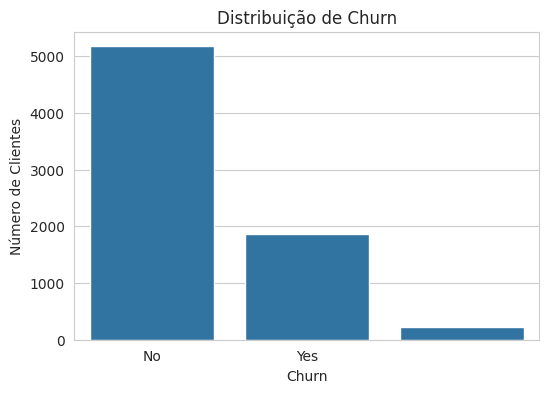

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de Clientes")
plt.show()

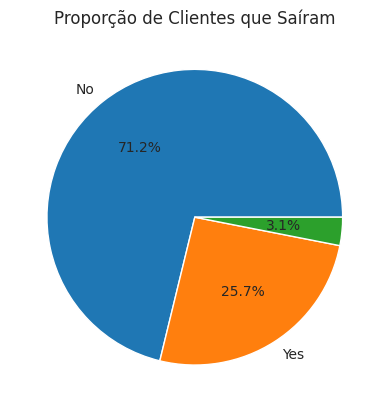

In [ ]:
df["Churn"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Proporção de Clientes que Saíram")
plt.ylabel("")
plt.show()

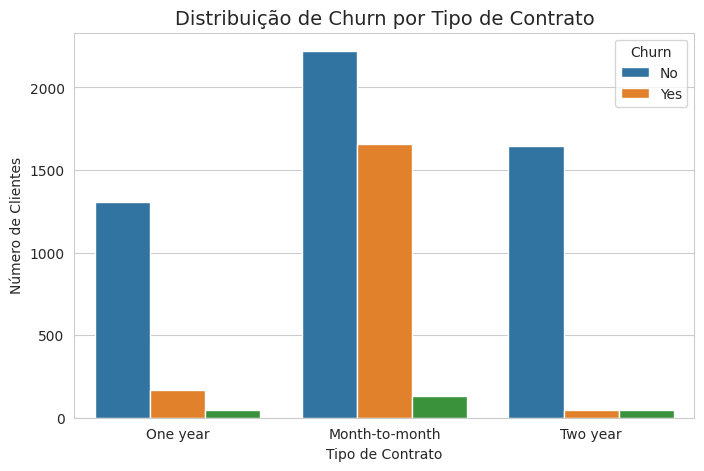

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.title("Distribuição de Churn por Tipo de Contrato", fontsize=14)
plt.xlabel("Tipo de Contrato")
plt.ylabel("Número de Clientes")

plt.show()

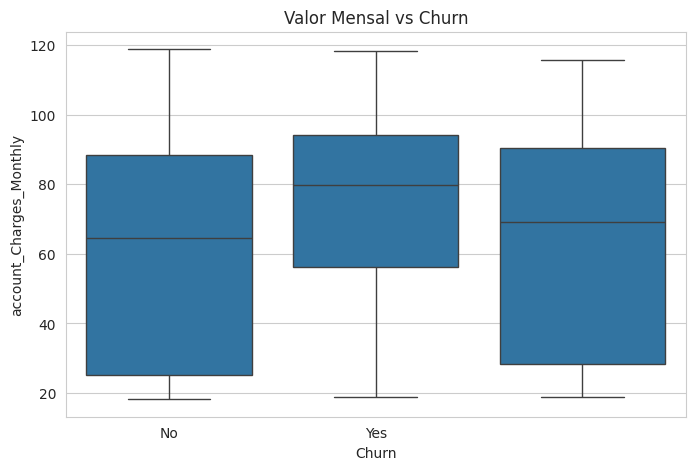

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="account_Charges_Monthly", data=df)
plt.title("Valor Mensal vs Churn")
plt.show()

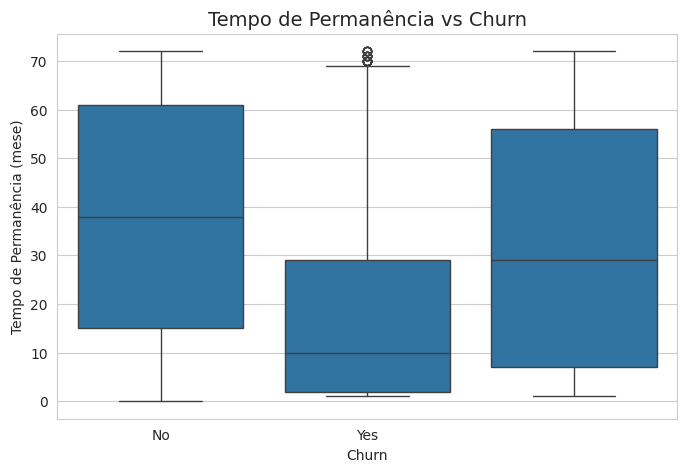

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="customer_tenure", data=df)
plt.title("Tempo de Permanência vs Churn", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Tempo de Permanência (meses)")
plt.show()

## Tempo de Permanência vs Churn

O gráfico mostra que clientes que cancelaram apresentam, em média, menor tempo de permanência na empresa.
Isso sugere que clientes novos possuem maior risco de evasão, indicando a importância de estratégias de retenção nos primeiros meses de contrato.



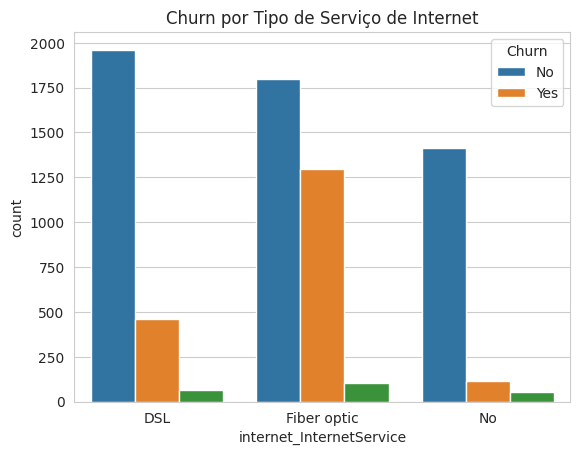

In [ ]:
sns.countplot(x="internet_InternetService", hue="Churn", data=df)
plt.title("Churn por Tipo de Serviço de Internet")
plt.show()

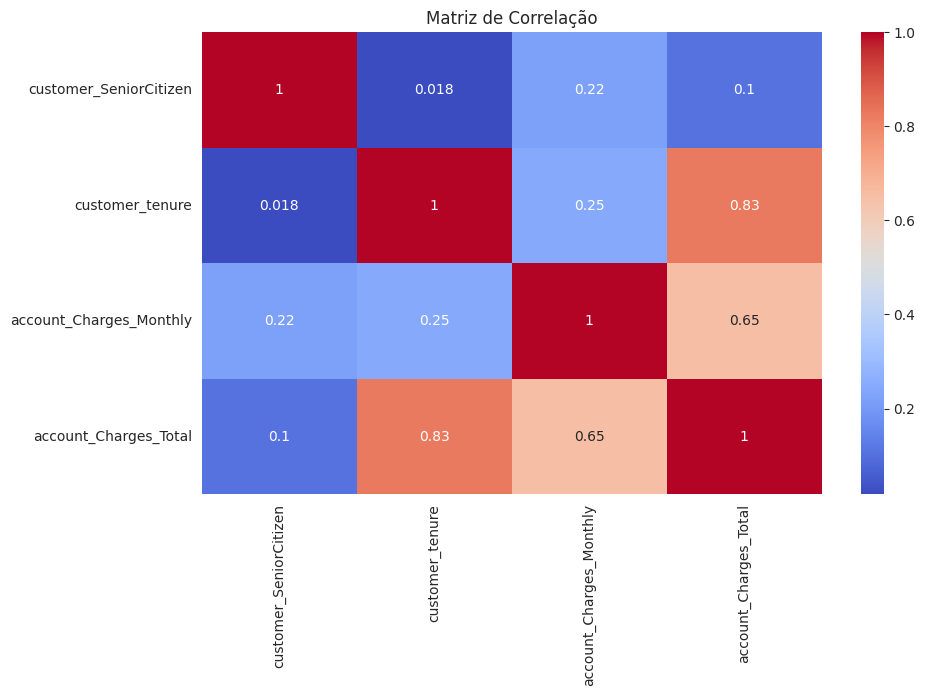

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

## Principais Insights

A análise dos dados revelou alguns padrões importantes relacionados à evasão de clientes:

- Clientes com contratos mensais apresentam maior taxa de Churn.
- Clientes com menor tempo de permanência na empresa tendem a cancelar  com mais frequência.
- Clientes com valores mensais mais altos também apresentam maior tendência de cancelamento.

Esses resultados indicam que clientes novos e com contratos mais flexíveis podem representar um grupo de maior risco de evasão.

 A taxa de Churn observada no dataset é de aproximadamente 25.71%, indicando um nível significativo de evasão de clientes.

In [ ]:
Churn_rate = df["Churn"].value_counts(normalize=True) * 100
Churn_rate

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


## Recomendações

Com base nos Insights obtidos na análise, algumas estratégias que podem ajudar a reduzir o Churn incluem:

- Incentivar contratos de longo por meio de descontos ou benefícios.
- Criar programas de fidelização para clientes nos primeiros meses de contrato.
- Oferecer suporte e acompanhamento para clientes com maiores valores de cobrança mensal.

Essas ações podem contribuir para melhorar a retenção de clientes e reduzir a taxa de Churn.